In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

from delayandsum import applyDAS

import matplotlib.pyplot as plt
import numpy as np

from jax import jit
from jax import numpy as jnp
from matplotlib import pyplot as plt

from jwave.geometry import TimeAxis
from jwave.geometry import Medium
from jwave.geometry import Domain
from jwave.geometry import Sensors, points_on_circle


from jwave import FourierSeries
from jwave.acoustics import simulate_wave_propagation
from jwave.geometry import *
from jwave.utils import show_field

import fbpinn_wave as fw
from fbpinns.analysis import FBPINN_solution
from fbpinns.analysis import load_model

from trampa import WaveTrampa

In [3]:
domain = Domain((240, 240), (35e-3/240/20, 35e-3/240/20))
medium = Medium(domain=domain, sound_speed=1490.0, attenuation=0.0, pml_size=6.0)
time_axis = TimeAxis.from_medium(medium, cfl=0.3, t_end=35e-6/20)
print(f"El dominio espacial en x va de {domain.spatial_axis[0].min()} m a {domain.spatial_axis[1].max()} m")
print(f"El dominio espacial en y va de {domain.spatial_axis[1].min()} m a {domain.spatial_axis[1].max()} m")

El dominio espacial en x va de -0.0008713541901670396 m a 0.0008713541901670396 m
El dominio espacial en y va de -0.0008713541901670396 m a 0.0008713541901670396 m


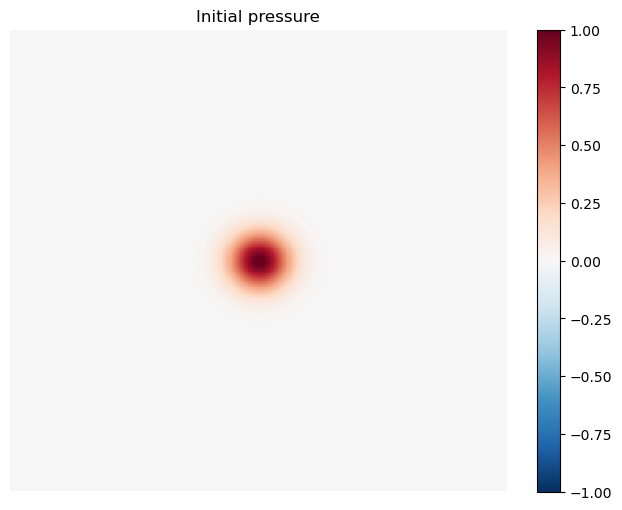

In [4]:
N = domain.N


x, y = np.mgrid[0:N[0], 0:N[1]]
mui = jnp.array([0, 0])/domain.dx[0] + np.array(N)/2
#mui = jnp.array([5e-3/20, 2e-3/20])/domain.dx[0] + np.array(N)/2
sigma = 1.5e-3/domain.dx[0]/20
p0 = jnp.exp(-0.5*(x-mui[0])**2/sigma**2) * jnp.exp(-0.5*(y-mui[1])**2/sigma**2)

p0 = FourierSeries(p0, domain)

show_field(p0)
plt.title("Initial pressure")
plt.show()

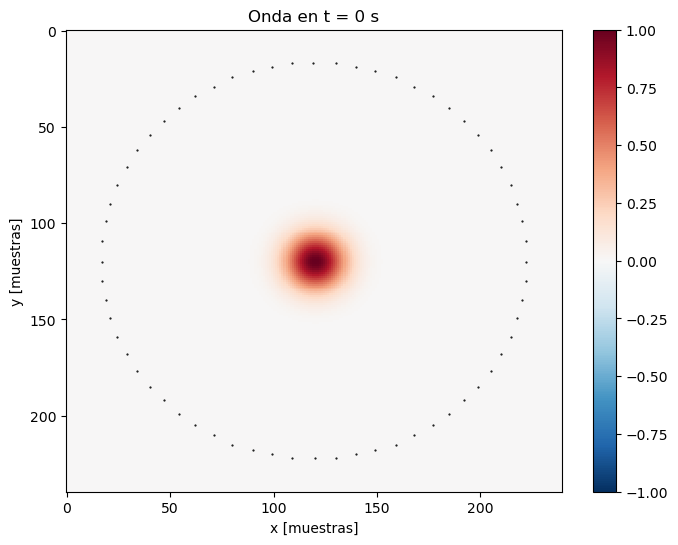

In [5]:
num_sensors = 64
rx = 15e-3/20
ri = rx/domain.dx[0]
xi, yi = points_on_circle(num_sensors, ri, (int(domain.N[0]/2), int(domain.N[0]/2)))
sensors_positions = (xi, yi)
sensors = Sensors(positions=sensors_positions)

show_field(p0)
plt.scatter(xi, yi, c='black', s=0.3)
plt.title("Onda en t = 0 s")
plt.xlabel("x [muestras]")
plt.ylabel("y [muestras]")
plt.axis('on')
plt.axis()
plt.show()

In [6]:
@jit
def compiled_simulator(medium, p0):
    a = simulate_wave_propagation(medium, time_axis, p0=p0, sensors=sensors)
    return a

@jit
def compiled_simulator2(medium, p0):
    a = simulate_wave_propagation(medium, time_axis, p0=p0)
    return a

p = compiled_simulator2(medium, p0)
sensors_data = compiled_simulator(medium, p0)[..., 0]


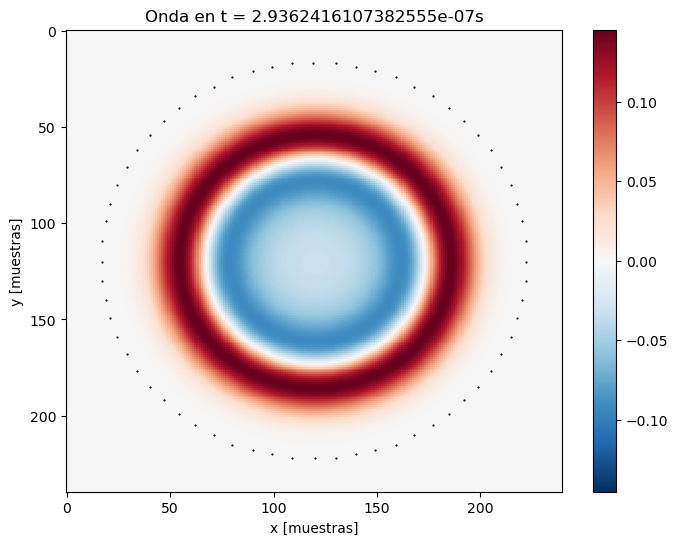

In [9]:
Nt = int(time_axis.Nt)
it = 200
i = it if it < Nt else Nt

dt = time_axis.dt

show_field(p[i], "Onda en t = " + str(i*dt) + "s")
plt.scatter(xi, yi, c='black', s=0.3)
plt.xlabel("x [muestras]")
plt.ylabel("y [muestras]")
plt.axis('on')
plt.axis()
plt.show()

In [9]:
def shift_solution_sinogram(s, r, c, mu, x, dt):
    '''
      Desplaza el sinograma de acuerdo a una fuente tipo pulso que no está centrada en el origen. Recibe:

      's': Sinograma para un pulso en el origen.

      'r': Distancia al origen de los sensores.

      'c': Velocidad de propagación de la onda. Se supone constante.

      'mu': Posición del nuevo pulso.

      'x': Posiciones de los sensores.

      'dt': Resolución temporal.

      Devuelve el sinograma dezplazado.

    '''
    s_new = np.zeros_like(s)
    for i, x_sens in enumerate(x):
        r_new = np.linalg.norm(x_sens - mu)
        diff = r - r_new
        fact = np.sqrt(r/r_new)
        shift = -int(diff/c/dt)
        s_new[i,:] = np.roll(s[i], shift)*fact

        if shift > 0:
            s_new[i,:shift] = np.zeros_like(s_new[i,:shift])
        else:
            s_new[i,shift + s.shape[1]:] = np.zeros_like(s_new[i,shift+s.shape[1]:])
    return s_new

x = (np.array(xi)- domain.N[0]/2)*domain.dx[0] # Escalo acá en vez de en el radio porque si lo hago antes la precisión del círcuo es mala 
y = (np.array(yi)- domain.N[1]/2)*domain.dx[0]
_field = FourierSeries(sensors_data.T, domain)
sinogram = _field.on_grid
#sinogram = fw.shift_solution_sinogram(sinogram, 15e-3/20, 1490, np.array([5e-3/20, 2e-3/20]), np.c_[x,y], time_axis.dt)
#sinogram = fw.shift_solution_sinogram(sinogram, 15e-3/20, 1490, np.array([0, 0]), np.c_[x,y], time_axis.dt)

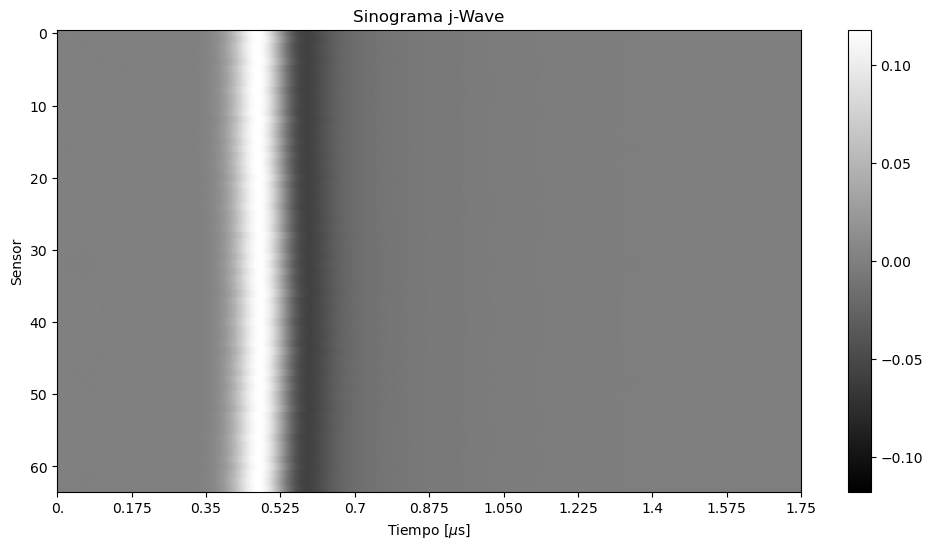

In [11]:
_field = FourierSeries(sensors_data.T, domain)
sinogram = _field.on_grid

t_new = time_axis.to_array()

plt.figure(figsize=(12,6))
maxval = jnp.amax(jnp.abs(sinogram))
plt.imshow(
    sinogram,
    cmap="gray", #"RdBu_r"
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] =np.format_float_positional((t_ticks[i]*(t_new[1]-t_new[0]))/1e-6, precision=3, )
plt.xticks(t_ticks, t_string)
plt.title("Sinograma j-Wave")
plt.xlabel("Tiempo [$\mu$s]")
plt.ylabel("Sensor")
plt.show()

In [20]:
WaveTrampa()

t = time_axis.to_array()
x = (np.array(xi)- domain.N[0]/2)*domain.dx[0]
y = (np.array(yi)- domain.N[1]/2)*domain.dx[0]

batch_shape = (len(x), t.shape[0])

xx, tt = np.meshgrid(x, t, indexing="xy")
yy, _ = np.meshgrid(y, t, indexing="xy")

const, model = load_model(run="test", i=200000, rootdir="pulse_2d_real_extended_fine1/results/")
_, all_params, _, active, _ = model

sinogram_fbpinn = FBPINN_solution(const, all_params, active, np.c_[xx.T.flatten(), yy.T.flatten(), tt.T.flatten()]).reshape(batch_shape)

[INFO] 2026-02-27 17:52:42 - Loading model from:
pulse_2d_real_extended_fine1/results/models/test/model_00200000.jax
[INFO] 2026-02-27 17:52:43 - x_batch
[INFO] 2026-02-27 17:52:43 - (76288, 3), float64, ndarray
[INFO] 2026-02-27 17:52:43 - x_take
[INFO] 2026-02-27 17:52:43 - (1354680, 3), float64, ndarray


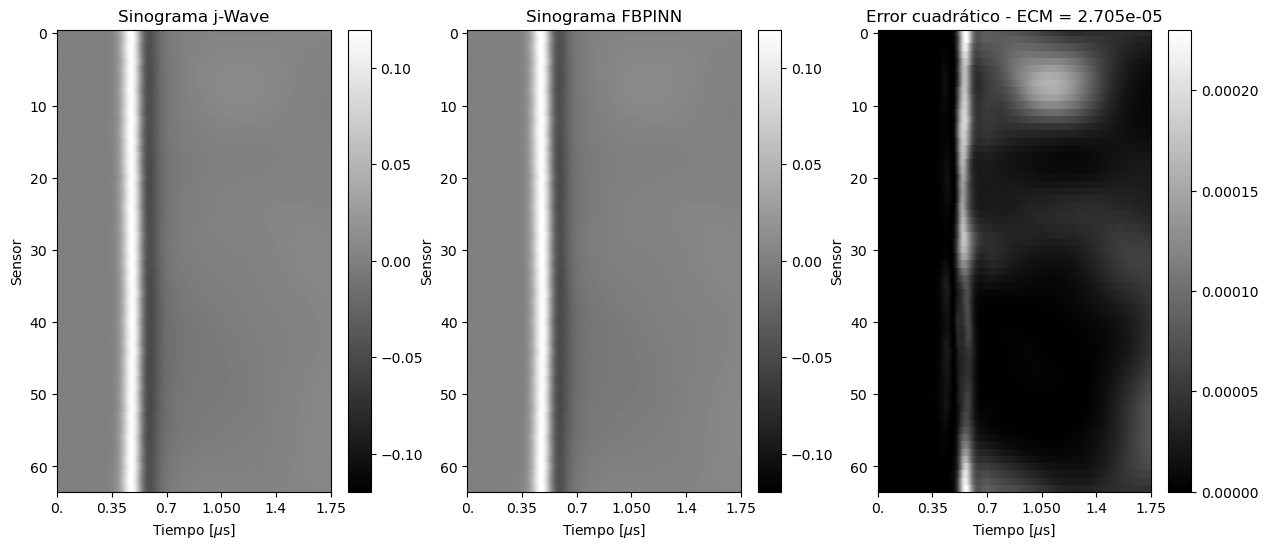

In [21]:
ec = (sinogram - sinogram_fbpinn)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)
t_new = time_axis.to_array()

plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
maxval = jnp.amax(jnp.abs(sinogram_fbpinn))
plt.imshow(
    sinogram_fbpinn,
    cmap="gray",
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 6

t_ticks = np.linspace(0, sinogram.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] =np.format_float_positional((t_ticks[i]*(t_new[1]-t_new[0]))/1e-6, precision=3, )
plt.xticks(t_ticks, t_string)
plt.title("Sinograma j-Wave")
plt.xlabel("Tiempo [$\mu$s]")
plt.ylabel("Sensor")

plt.subplot(1,3,2)
plt.imshow(
    sinogram_fbpinn,
    cmap="gray",
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()

num = 6
t_ticks = np.linspace(0, sinogram.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] =np.format_float_positional((t_ticks[i]*(t_new[1]-t_new[0]))/1e-6, precision=3, )

plt.xticks(t_ticks, t_string)
plt.title("Sinograma FBPINN")
plt.xlabel("Tiempo [$\mu$s]")
plt.ylabel("Sensor")

plt.subplot(1,3,3)
plt.imshow(
    ec,
    cmap="gray",
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()

num = 6
t_ticks = np.linspace(0, sinogram.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] =np.format_float_positional((t_ticks[i]*(t_new[1]-t_new[0]))/1e-6, precision=3, )

plt.xticks(t_ticks, t_string)
plt.title("Error cuadrático - ECM = " + str(ecm))
plt.xlabel("Tiempo [$\mu$s]")
plt.ylabel("Sensor")

plt.show()

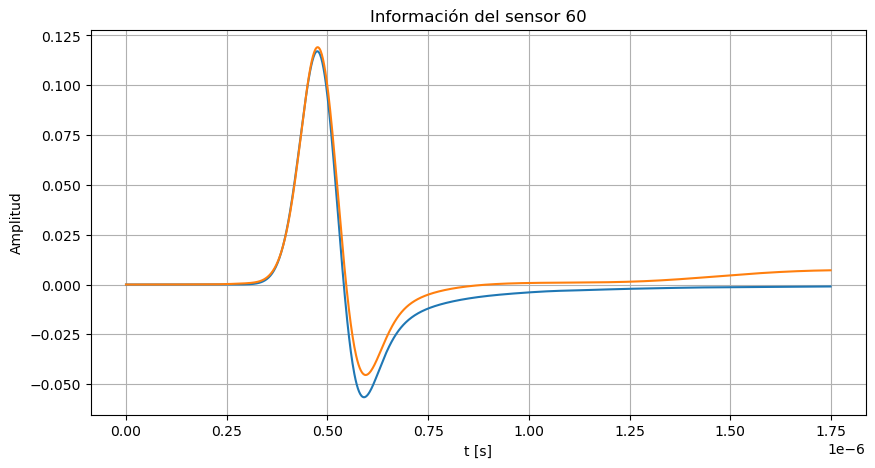

In [22]:
#Comparación por sensores

id = 60
sensor = sinogram[id,:]
sensor_fbpinn = sinogram_fbpinn[id,:]
t_axis = time_axis.to_array()

plt.figure(figsize=(10,5))

plt.grid()
plt.title(f"Información del sensor {id}")
plt.plot(t_axis, sensor)
plt.plot(t_axis, sensor_fbpinn)
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.show()

## Figuras de mérito

In [23]:
print("Para sinogramas:\n")
_ = fw.metricas_imagen(sinogram, sinogram_fbpinn)

Para sinogramas:



MSE = 2.705e-05
RMSE = 5.201e-03
PSNR = 30.623352394622966
SSIM = 0.9936330162261338
PCC = 0.9904189397174252


Para reconstrucciones con DAS entre sí:

MSE = 6.723e-02
RMSE = 2.593e-01
PSNR = 27.055327482761037
SSIM = 0.7877162511832974
PCC = 0.9997545859222193

Para reconstrucciones con DAS respecto a la presión original:

j-wave:
MSE = 2.609e+00
RMSE = 1.615e+00
PSNR = 10.766800861967543
SSIM = 0.5179336684198255
PCC = 0.7929950750128417

FBPINNs
MSE = 3.334e+00
RMSE = 1.826e+00
PSNR = 10.252119145027054
SSIM = 0.48371652578437874
PCC = 0.7902492734188392


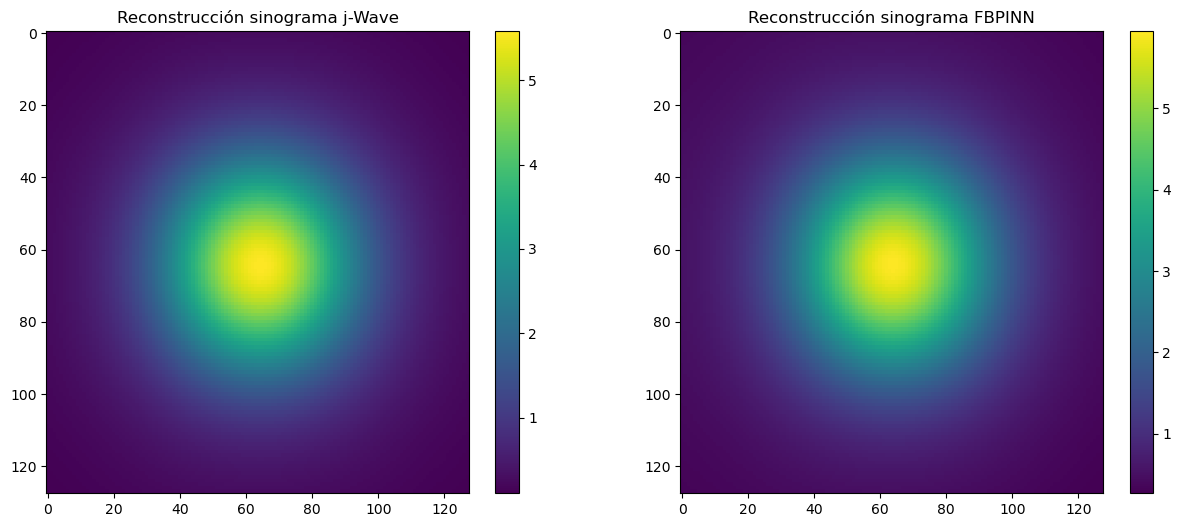

In [24]:
Pjwave = applyDAS(sinogram.shape[0],sinogram.shape[1],35e-3/128/3.5/20,128,rx,360,1490,0,35e-6/20,sinogram).T
Pfbpinn = applyDAS(sinogram.shape[0],sinogram.shape[1],35e-3/128/3.5/20,128,rx,360,1490,0,35e-6/20,sinogram_fbpinn).T

N = [128,128]

x, y = np.mgrid[0:N[0], 0:N[1]]
mui = jnp.array([0, 0])/domain.dx[0] + np.array(N)/2
sigma = 1.5e-3/domain.dx[0]/20
p0 = jnp.exp(-0.5*(x-mui[0])**2/sigma**2) * jnp.exp(-0.5*(y-mui[1])**2/sigma**2)

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
maxval = jnp.amax(jnp.abs(Pjwave))
plt.imshow(
    Pjwave,
    aspect="auto",
)
plt.title("Reconstrucción sinograma j-Wave")
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(
    Pfbpinn,
    aspect="auto",
)
plt.colorbar()
plt.title("Reconstrucción sinograma FBPINN")

print("Para reconstrucciones con DAS entre sí:\n")
_ = fw.metricas_imagen(Pjwave, Pfbpinn)

print("\nPara reconstrucciones con DAS respecto a la presión original:\n")
print("j-wave:")
_ = fw.metricas_imagen(Pjwave, p0)
print("\nFBPINNs")
_ = fw.metricas_imagen(p0, Pfbpinn)

In [43]:
from fbpinns.domains import RectangularDomainND
import jax

key = jax.random.PRNGKey(0)

domain = RectangularDomainND
sampler = "halton"

# 2D

xmin, xmax = jnp.array([-17.5e-3,-17.5e-3,0]), jnp.array([17.5e-3,17.5e-3,35e-6])

batch_shapes = ((20,20),(20,20),(20,20),(20,20),(0,0),(0,0))
batch_shape = (50,50,60)

ps_ = domain.init_params(xmin, xmax)
all_params = {"static":{"domain":ps_[0]}, "trainable":{"domain":ps_[1]}}


x_batch = domain.sample_interior(all_params, key, sampler, batch_shape)
x_batches = domain.sample_boundaries(all_params, key, sampler, batch_shapes)


'''fig = plt.figure()
ax = fig.add_subplot(projection='3d')
for x_batch in x_batches:
    x = x_batch[:,0]
    y = x_batch[:,1]
    z = x_batch[:,2]

    ax.scatter(x, y, z)
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Movable 3D Scatter Plot')

plt.show()'''

"fig = plt.figure()\nax = fig.add_subplot(projection='3d')\nfor x_batch in x_batches:\n    x = x_batch[:,0]\n    y = x_batch[:,1]\n    z = x_batch[:,2]\n\n    ax.scatter(x, y, z)\nax.set_xlabel('X-axis')\nax.set_ylabel('Y-axis')\nax.set_zlabel('Z-axis')\nax.set_title('Movable 3D Scatter Plot')\n\nplt.show()"

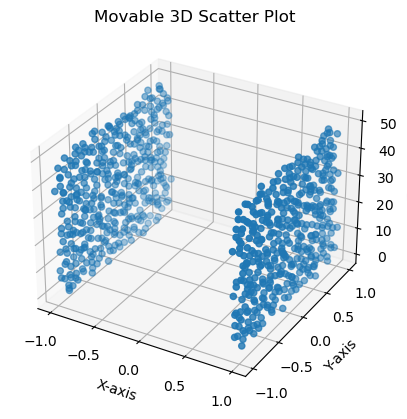

In [ ]:
from fbpinns.domains import RectangularDomainND
import jax

key = jax.random.PRNGKey(0)

domain = RectangularDomainND
sampler = "halton"

xmin, xmax = jnp.array([-1,-1,0]), jnp.array([1,1,50])
batch_shape = (20,20,20)

ps_ = domain.init_params(xmin, xmax)
all_params = {"static":{"domain":ps_[0]}, "trainable":{"domain":ps_[1]}}

x_batch = domain.sample_interior(all_params, key, sampler, batch_shape)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

x = x_batch[:,0]
y = x_batch[:,1]
z = x_batch[:,2]

i_pml1 = x < -0.9
i_pml2 = x > 0.9
i_pml = i_pml1 | i_pml2

alfa_max = 2

alfa = alfa_max*((x[i_pml] - ))**2

ax.scatter(x[i_pml], y[i_pml], z[i_pml])
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Movable 3D Scatter Plot')

plt.show()


In [43]:
x = jnp.arange(10)
y = jnp.linspace(0,1,10)
jnp.where(x > 4, y, 0)

Array([0.       , 0.       , 0.       , 0.       , 0.       , 0.5555556,
       0.6666667, 0.7777778, 0.8888889, 1.       ], dtype=float32)